In [203]:
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path
from ipywidgets import interact, fixed
from qsmp.viz import viz
from qsmp.viz import apps
import ipywidgets as widgets
from scipy.io import savemat
from qsmp import tree
from spectrum import MultiTapering

In [204]:
plt.rcParams.update({
    "text.usetex": True,    
    "font.size": 12
})
img_dir = Path('../results/img/')

In [205]:
data_file = Path('../data/morlet/morlet_signal.npz')
with np.load(data_file, allow_pickle=True) as data:
    T = data['T']
    fs = data['fs']
    wave_len = data['wave_len']
    freq = data['freq']
    SNRdB = data['SNRdB']

In [206]:
interact(
    viz.show_segment_start, T=fixed(T), text=fixed('the time series'),
    wave_len=fixed(wave_len), n_seg=(3, 10), start=(0, 10*wave_len)
);

interactive(children=(IntSlider(value=4, description='n_seg', max=10, min=3), IntSlider(value=1000, descriptio…

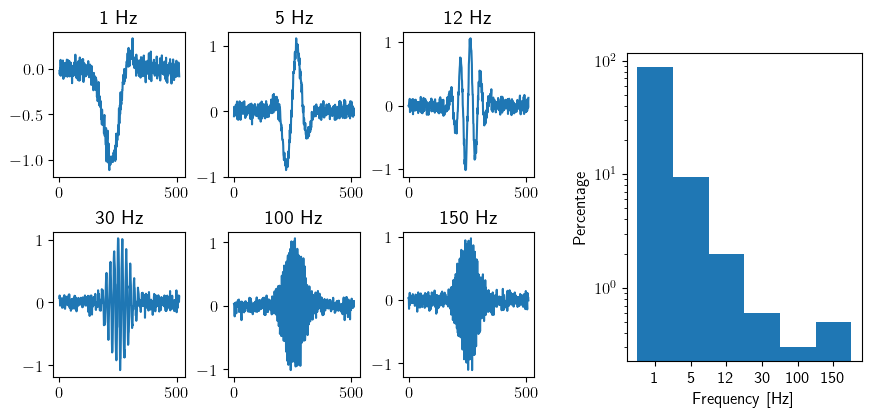

In [118]:
unique_freqs, freq_idx, freq_counts = np.unique(
    freq, return_index=True, return_counts=True
)

freq_pct = 100*freq_counts/freq_counts.sum()

idx = freq_idx * wave_len
fig, axd = plt.subplot_mosaic([['1',  '5',   '12', 'hist', 'hist'],
                               ['30', '100', '150', 'hist', 'hist']
                              ], figsize=(8, 4), layout='compressed')
for i, t in enumerate(idx):
    k = str(unique_freqs[i])
    axd[k].plot(T[idx[i]:t+wave_len])
    axd[k].set_title(f'{k} Hz')
    
axd['hist'].bar(np.arange(unique_freqs.size), freq_pct, width=1)
axd['hist'].set_xticks(np.arange(unique_freqs.size), [str(i) for i in unique_freqs])
axd['hist'].set_xlabel('Frequency [Hz]')
axd['hist'].set_ylabel('Percentage')
axd['hist'].set_yscale('log')
l, b, w, h = axd['hist'].get_position().bounds
axd['hist'].set_position([l+0.17, b, w, h])
fpath = img_dir.joinpath('morlet_waves_hist.pdf')
plt.savefig(fpath, bbox_inches='tight', pad_inches=0)

In [119]:
freq_pct

array([87.1,  9.5,  2. ,  0.6,  0.3,  0.5])

In [207]:
in_file = Path('../results/morlet/qsmp_m-512_sigma-0.9_1.0_1.1_1.2_2.0_rect-50_minfilt-256.npz')
with np.load(in_file) as data:
    density = data['density'].T
    NNdist = data['profile'].T
    NNindex = data['indices'].T

In [208]:
sigmas = sigmas = [0.9, 1.0, 1.1, 1.2, 2.0] #[1.0, 2.0, 4.0, 8.0, 16.0]
sigmas = dict(zip(sigmas, np.arange(len(sigmas))))
interact(
    viz.show_density, density=fixed(density), sigma=sigmas, wave_len=fixed(wave_len), n_seg=(1, 100)
);

interactive(children=(Dropdown(description='sigma', options={0.9: 0, 1.0: 1, 1.1: 2, 1.2: 3, 2.0: 4}, value=0)…

In [209]:
#XXX: This does NOT work on VS Code. It works fine on Chrome.
apps.modes_across_maxdist(T, wave_len, density,
                          NNindex, NNdist, sigmas)

In [210]:
apps.modes_across_sigma(T, wave_len, density, NNindex, NNdist, list(sigmas.keys()))

In [13]:
mat_file = Path('../data/morlet/morlet_signal.mat')
with mat_file.open('wb') as f:
    savemat(f, dict(T=T, fs=fs, wave_len=wave_len, freq=freq, SNRdB=SNRdB))

In [120]:
(freq==100).nonzero()[0]*wave_len

array([  9728, 102912, 352256])

In [3]:
files = [
    Path('../results/morlet/qsmp_m512_sigma1.0_2.0_4.0_8.0_16.0_rect-50.npz'),
    Path('../results/morlet/qsmp_m-512_sigma-0.9_1.0_1.1_1.2_2.0_rect-50_minfilt-128.npz'),
    Path('../results/morlet/qsmp_m-512_sigma-0.9_1.0_1.1_1.2_2.0_rect-50_minfilt-256.npz'),
    Path('../results/morlet/qsmp_m-512_sigma-0.9_1.0_1.1_1.2_2.0_rect-50_minfilt-1024.npz')
]

i_sigma = [0, 1, 1, 1]
density_list = [0] * 4
NNdist_list = [0] * 4
NNindex_list = [0] * 4

for i in range(4):
    with np.load(files[i]) as data:
        density_list[i] = data['density'][:, i_sigma[i]]
        NNdist_list[i] = data['profile'][:, i_sigma[i]]
        NNindex_list[i] = data['indices'][:, i_sigma[i]]

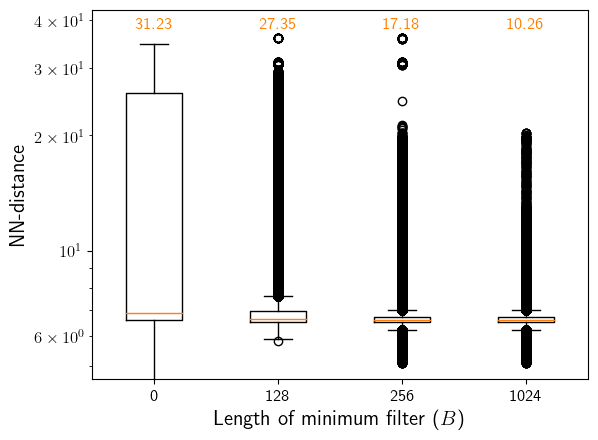

In [271]:
minFilt_len_labels = ['0', '128', '256', '1024']
quantiles = [np.quantile(NNdist_list[i], .999) for i in range(4)]
data = np.vstack(NNdist_list).T
fig, ax = plt.subplots()
ax.boxplot(data);
ax.set_yscale('log')
ax.set_xticks(np.arange(1,5), minFilt_len_labels)
ax.set_xlabel('Length of minimum filter ($B$)', fontsize=15)
ax.set_ylabel('NN-distance', fontsize=15)
for i, q in enumerate(quantiles):
    ax.annotate(f"{q:.2f}", xy=(i+.85, data.max()+2), color='#ff7f00', weight='extra bold')
ylim = ax.get_ylim()
ax.set_ylim([ylim[0], ylim[1]+3])
fpath = img_dir.joinpath('minFilt_NNdist_boxplot.pdf')
plt.savefig(fpath, bbox_inches='tight', pad_inches=0)

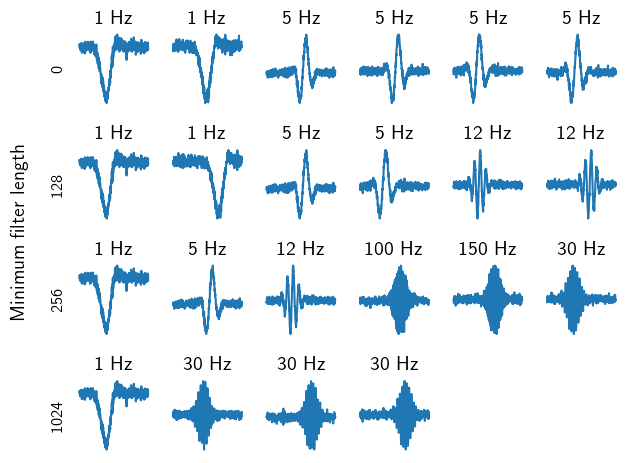

In [345]:
max_dist = 7.9
max_modes, n_neighbors = 6, 0
subseq_len = 512
fig, ax = plt.subplots(4, 6)
for i in range(4):
    NNd, NNi, modes, cluster_size = tree.tree2clusters(
        subseq_len, density_list[i], NNindex_list[i],
        NNdist_list[i], max_dist
    )

    sample, idx = tree.get_neighbors(
        T, subseq_len, density_list[i], NNi,
        NNd, modes, max_modes, n_neighbors
    )
    modes = np.vstack([m[0] for m in sample])
    for j in range(6):
        if j < len(modes):
            mts = MultiTapering(modes[j], NW=3, sampling=fs)
            PSD, f = mts.psd, mts.frequencies()
            f_max = f[np.argmax(PSD)]
            f_max = 1.0 if f_max == 0 else f_max
            ax[i, j].plot(modes[j])
            ax[i, j].set_title(f'{f_max:.0f} Hz')
        if j == 0:
            ax[i, j].set_ylabel(minFilt_len_labels[i])
        ax[i,j].set_frame_on(False)
        ax[i,j].set_xticks([])
        ax[i,j].set_yticks([])
fig.supylabel('Minimum filter length')
plt.tight_layout()
fpath = img_dir.joinpath('minFilt-len_modes.pdf')
# plt.savefig(fpath, bbox_inches='tight', pad_inches=0)

In [198]:
NNd, NNi, modes, cluster_size = tree.tree2clusters(
    wave_len, density_list[2], NNindex_list[2],
    NNdist_list[2], 7.9
)
sample, idx = tree.get_neighbors(
    T, wave_len, density_list[2], NNi,
    NNd, modes, 6, 1
)

In [199]:
idx = [i[0] for i in idx]
print(idx)

[386073, 85992, 388161, 9683, 185295, 51773]


In [202]:
NNdist_list[2][idx]

array([ 0.        , 24.62080359, 30.60656007, 30.8903873 , 31.01966349,
       31.10691415])

In [187]:
import copy
NNind = NNindex_list[2]
children_list = []
for i in np.arange(5,0,-1):
    child = idx[i]
    roots = copy.deepcopy(idx)
    roots.pop(i)    
    parent = NNind[child]
    children = [parent]
    while parent not in roots:
        child = parent
        parent = NNind[child]
        children.append(parent)

    children = np.array(children)    
    isort = np.argsort(children)
    iisort = np.argsort(isort)
    children = unsorted_children[isort]
    start_arr = (np.r_[True, np.diff(children)>wave_len/4]).nonzero()[0]
    end_arr = np.r_[start_arr[1:], children.size]
    n_roots = start_arr.size
    winning_roots = np.zeros(n_roots, dtype=np.int64)
    winning_roots_idx = np.zeros(n_roots, dtype=np.int64)
    isort = np.argsort(roots)
    roots_sorted = children[isort]
    for j, (start, end) in enumerate(zip(start_arr, end_arr)):
        imax = np.argmax(density_list[2][children[start:end]])
        winning_roots[j] = children[start + imax]
        winning_roots_idx[j] = start + imax

    tmp = np.full(children.shape, fill_value=False)
    tmp[winning_roots_idx] = True
    children = children[iisort][tmp[iisort]]
    n_children = children.size
    children_idx = np.linspace(0, n_children-1, 4).astype(int)
    children = children[children_idx]  
    if parent not in children:
        children = np.r_[children, parent]
    children = np.r_[idx[i], children]
    children_list.append(children)
children_list

[array([ 51773, 324017, 164242, 499646,  85992]),
 array([185295, 388023, 287123, 499616,  85960,  85992]),
 array([  9683, 388019,  11200, 388023, 388028, 386073]),
 array([388161, 324017,  11278, 388078, 164242,  85992]),
 array([ 85992, 388064, 388078, 499597, 499598, 386073])]

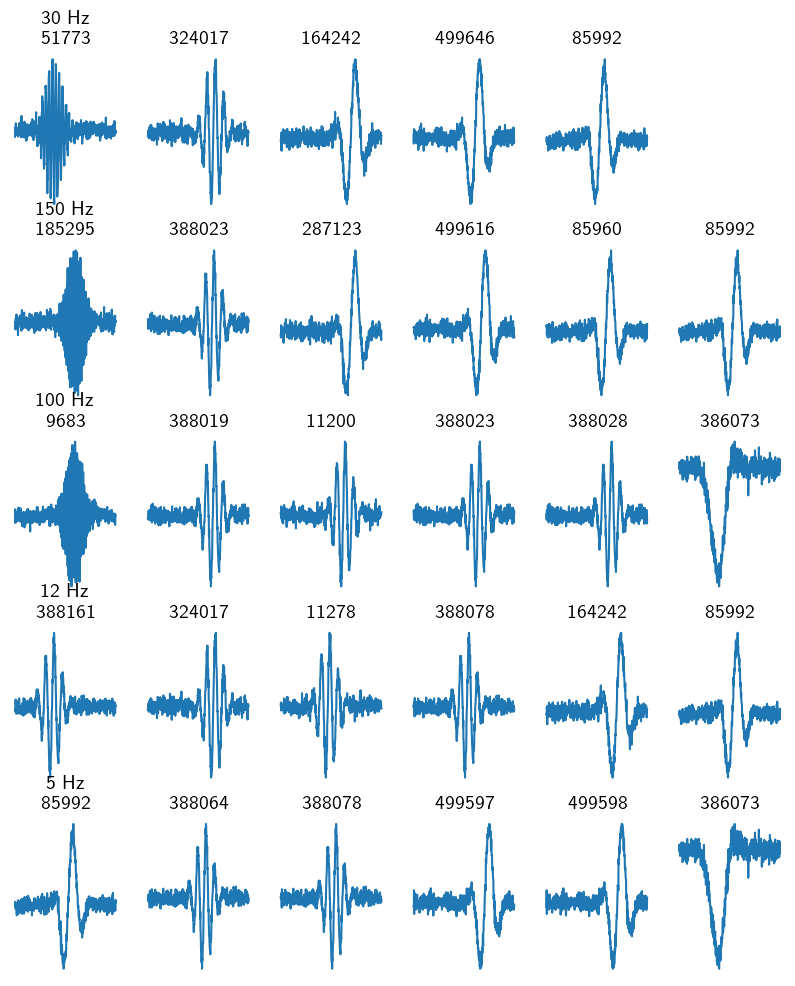

In [196]:
fig, ax = plt.subplots(5, 6, figsize=(10,12))
for i in range(5):
    for j in range(6):        
        ax[i,j].axis('off')
        if j < children_list[i].size:
            t = children_list[i][j]
            wave = T[t:t+wave_len]            
            ax[i,j].plot(wave)  
            if j == 0:
                mts = MultiTapering(wave, NW=3, sampling=fs)
                PSD, f = mts.psd, mts.frequencies()
                f_max = f[np.argmax(PSD)]
                f_max = 1.0 if f_max == 0 else f_max
                ax[i, j].set_title(f'{f_max:.0f} Hz\n{t}')
            else:
                ax[i, j].set_title(f'{t}')

fpath = img_dir.joinpath('tree_cartoon.svg')
# plt.savefig(fpath, bbox_inches='tight', pad_inches=0)

In [52]:
i = 1


(NNind == idx[i][0]).nonzero()[0]

array([275047, 371695])

In [53]:
child = 275047
parent = NNind[child]
while parent != child:
    print(child, parent)
    child = parent
    parent = NNind[child]    

275047 85992
85992 509815
509815 24935
24935 415593
415593 24937
24937 362860
362860 24938
24938 362861
362861 24939
24939 362862
362862 24941
24941 415596
415596 24942
24942 362866
362866 24943
24943 362868
362868 24944
24944 362869
362869 24945
24945 362871
362871 24946
24946 415603
415603 24947
24947 415606
415606 24948
24948 415608
415608 24949
24949 415610
415610 24950
24950 415612
415612 24951
24951 415614
415614 24954
24954 415619
415619 24956
24956 181712
181712 385482
385482 181714
181714 385493
385493 181715
181715 385504
385504 181729
181729 385576
385576 181791
181791 385579
385579 181802
181802 459793
459793 181804
181804 25040
25040 386024
386024 33764
33764 25050
25050 386042
386042 386073


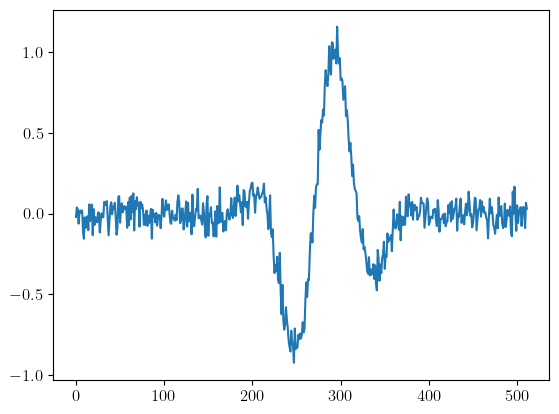

In [60]:
j = 85992 #275047 #386042 #415606 #24935 #509815
plt.plot(T[j:j+wave_len])